# Demo Notebook 2 — Sample Questions & Reference Analysis

This notebook walks through the **Category 3** questions (brain state from EEG) and shows, for each, the **reference analysis** that derives the ground-truth answer from the raw data — the analysis a model must reproduce.

Two integrity properties are demonstrated throughout:

1. **The answer is derivable** from an objective property of the signal (spectral analysis), not looked up.
2. **The label is withheld from the model.** The model sees only the EEG (via a redacted `ToolSession`); the ground-truth *resolver* uses the full file (including the `intervals` label tables) to verify the answer.


## Setup

In [1]:
import pathlib
import sys

_here = pathlib.Path.cwd()
ROOT = next((p for p in [_here, *_here.parents] if (p / "pyproject.toml").exists()), _here)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from agent.tools import ToolSession
from benchmark import ground_truth, verify_ground_truth
from data.nwb_access import load_nwb

%matplotlib inline
plt.rcParams["figure.figsize"] = (10, 4)

QUESTIONS = {q["id"]: q for q in verify_ground_truth.load_questions()}
ANSWERS = verify_ground_truth.load_answers()
print(f"loaded {len(QUESTIONS)} questions")

loaded 20 questions


## Anatomy of a question

Each question names the asset/window, an `answer_type`, a `redaction` list (what to withhold from the model), and a `ground_truth` resolver used to (re)compute the answer.

In [2]:
import json

q = QUESTIONS["C3-Q01"]
print(json.dumps(q, indent=2))
print("\nstored answer:", ANSWERS["C3-Q01"]["answer"])

{
  "id": "C3-Q01",
  "category": 3,
  "title": "Brain state @ 600s (sub-521885)",
  "prompt": "The provided EEG recording (channel 0) is a 30-second epoch beginning at t=600 s from a mouse cortical EEG session. The experimental state labels have been withheld. Compute the power spectral density of this epoch and, based on its spectral signature, classify the animal's brain state. Is the animal (A) awake or (B) under isoflurane anesthesia?",
  "source": {
    "dandi_id": "000458",
    "version": "0.230317.0039",
    "asset_path": "sub-521885/sub-521885_ses-20200709_behavior+ecephys.nwb",
    "channel": 0,
    "window": {
      "start_s": 600.0,
      "duration_s": 30.0
    }
  },
  "redaction": [
    "intervals"
  ],
  "answer_type": "mcq",
  "choices": {
    "A": "awake",
    "B": "anesthetized"
  },
  "ground_truth": {
    "method": "state_at_window",
    "params": {
      "start_s": 600.0,
      "duration_s": 30.0
    }
  }
}

stored answer: awake


## Reference analysis 1 — brain state classification (Q01 vs Q02)

Q01 (awake) and Q02 (anesthetized) come from the *same* session at different times. We open the recording once and use a **redacted** `ToolSession` (no access to `intervals`) — exactly what the model gets — to compute the PSD of each window. Anesthesia raises low-frequency (delta) power.

In [3]:
q1, q2 = QUESTIONS["C3-Q01"], QUESTIONS["C3-Q02"]
src = q1["source"]
handle = load_nwb(src["dandi_id"], src["version"], src["asset_path"])

# The model's view: redacted session (intervals withheld).
model_view = ToolSession(redaction=["intervals"], nwb=handle.nwb)

psd_awake = model_view.compute_psd(**{k: q1["source"]["window"][k] for k in ("start_s", "duration_s")}, channel=0)
psd_anes = model_view.compute_psd(**{k: q2["source"]["window"][k] for k in ("start_s", "duration_s")}, channel=0)

for label, psd in [("Q01", psd_awake), ("Q02", psd_anes)]:
    print(f"{label}: dominant={psd['dominant_band']:>5}  peak={psd['peak_frequency_hz']:.2f} Hz  "
          f"delta_power={psd['band_powers']['delta']:.4f}")

Q01: dominant=theta  peak=6.00 Hz  delta_power=730.9315
Q02: dominant=delta  peak=0.50 Hz  delta_power=6439.2451


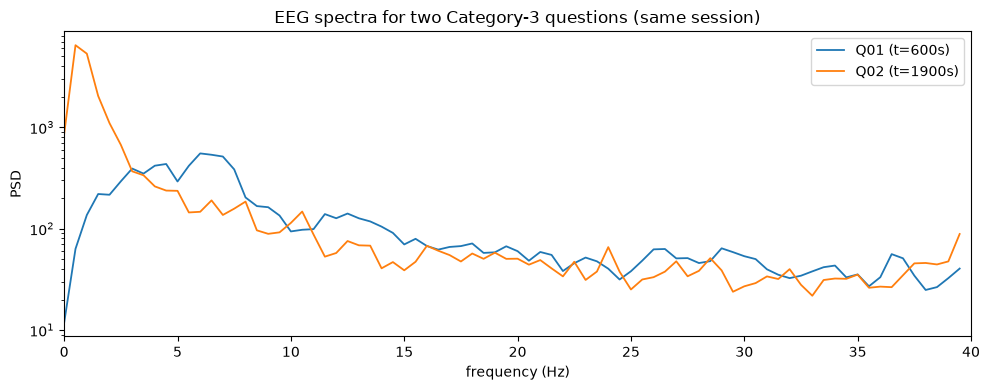

In [4]:
plt.semilogy(psd_awake["freqs_hz"], psd_awake["psd"], label="Q01 (t=600s)", lw=1.3)
plt.semilogy(psd_anes["freqs_hz"], psd_anes["psd"], label="Q02 (t=1900s)", lw=1.3)
plt.xlim(0, 40)
plt.xlabel("frequency (Hz)")
plt.ylabel("PSD")
plt.title("EEG spectra for two Category-3 questions (same session)")
plt.legend()
plt.tight_layout()
plt.show()

### Verifying the ground truth

The model would infer the state from the spectra above. The **resolver** independently reads the withheld `intervals` table (full-file access) to confirm the authored answer — proving the label is real and non-circular.

In [5]:
for qid in ("C3-Q01", "C3-Q02"):
    qq = QUESTIONS[qid]
    derived = ground_truth.resolve(handle.nwb, qq["ground_truth"])
    stored = ANSWERS[qid]["answer"]
    print(f"{qid}: resolver={derived!r}  stored={stored!r}  match={derived == stored}")

C3-Q01: resolver='awake'  stored='awake'  match=True
C3-Q02: resolver='anesthetized'  stored='anesthetized'  match=True


## Reference analysis 2 — detecting anesthesia onset (Q09)

Q09 withholds all labels and asks *when* the animal enters stable anesthesia. On this session the delta/total *ratio* barely separates the states, but the **absolute delta-band power** shows an unmistakable sustained surge at anesthesia onset. The reference method scans the session with the redacted tool the model has, and flags the first window whose delta power rises far above the awake baseline (a z-score threshold) — a genuinely computational ("superhuman") detection. We compare the detected onset to the resolver's metadata value (the `isoflurane_anesthesia` epoch start).

*(We target the anesthesia-epoch onset, not the gas-on instant, since the EEG signature is what a spectral detector can resolve.)*

In [6]:
q9 = QUESTIONS["C3-Q09"]
src9 = q9["source"]
h9 = load_nwb(src9["dandi_id"], src9["version"], src9["asset_path"])
scan_view = ToolSession(redaction=["intervals"], nwb=h9.nwb)

times = np.arange(600, 2400, 30.0)
delta_power = np.array(
    [scan_view.compute_psd(float(t), 30.0, channel=0)["band_powers"]["delta"] for t in times]
)

# Baseline = early (awake) windows; flag the first big deviation above it.
base = delta_power[times < 1200]
threshold = base.mean() + 5 * base.std()
crossings = np.where(delta_power > threshold)[0]
detected = float(times[crossings[0]]) if len(crossings) else float("nan")

truth_onset = ground_truth.resolve(h9.nwb, q9["ground_truth"])
print(f"awake baseline delta power = {base.mean():.0f} ± {base.std():.0f}   threshold = {threshold:.0f}")
print(f"detected onset ~ {detected:.0f} s   |   resolver onset = {truth_onset:.2f} s   |   tolerance = ±{q9['tolerance']} s")
print(f"within tolerance: {abs(detected - truth_onset) <= q9['tolerance']}")

awake baseline delta power = 23347 ± 4528   threshold = 45987
detected onset ~ 1710 s   |   resolver onset = 1684.09 s   |   tolerance = ±120.0 s
within tolerance: True


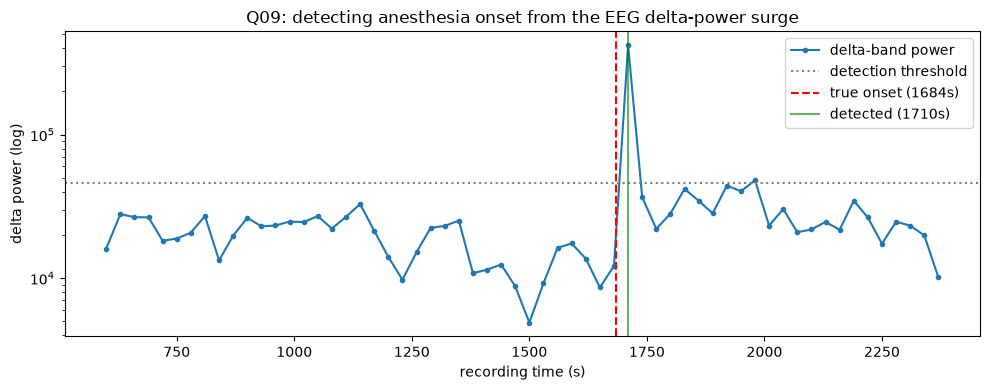

In [7]:
plt.semilogy(times, delta_power, marker="o", ms=3, label="delta-band power")
plt.axhline(threshold, color="gray", ls=":", label="detection threshold")
plt.axvline(truth_onset, color="red", ls="--", label=f"true onset ({truth_onset:.0f}s)")
plt.axvline(detected, color="green", ls="-", alpha=0.6, label=f"detected ({detected:.0f}s)")
plt.xlabel("recording time (s)")
plt.ylabel("delta power (log)")
plt.title("Q09: detecting anesthesia onset from the EEG delta-power surge")
plt.legend()
plt.tight_layout()
plt.show()
h9.close()

## Reference analysis 3 — multi-part question (Q10)

Q10 asks for both the brain state and the dominant frequency band. Each part has its own resolver and is graded independently (partial credit).

In [8]:
q10 = QUESTIONS["C3-Q10"]
src10 = q10["source"]
h10 = load_nwb(src10["dandi_id"], src10["version"], src10["asset_path"])
w = src10["window"]
psd10 = ToolSession(redaction=["intervals"], nwb=h10.nwb).compute_psd(w["start_s"], w["duration_s"], channel=0)
print("analysis  -> dominant band:", psd10["dominant_band"], "| peak:", psd10["peak_frequency_hz"], "Hz")
for part in q10["parts"]:
    print(f"part {part['key']:>5}: resolver={ground_truth.resolve(h10.nwb, part['ground_truth'])!r}")
print("stored answer:", ANSWERS["C3-Q10"]["answer"])
h10.close(); handle.close()

analysis  -> dominant band: delta | peak: 0.5 Hz
part state: resolver='anesthetized'
part  band: resolver='delta'
stored answer: {'band': 'delta', 'state': 'anesthetized'}


## The full Category-3 question set

In [9]:
rows = []
for qid, qq in QUESTIONS.items():
    rows.append({
        "id": qid,
        "type": qq["answer_type"],
        "title": qq.get("title", ""),
        "truth": ANSWERS[qid]["answer"],
    })
pd.DataFrame(rows)

,id,type,title,truth
0,C3-Q01,mcq,Brain state @ 600s (sub-521885),awake
1,C3-Q02,mcq,Brain state @ 1900s (sub-521885),anesthetized
2,C3-Q03,mcq,Brain state @ 800s (sub-521886),awake
3,C3-Q04,mcq,Brain state @ 2210s (sub-551399),anesthetized
4,C3-Q05,mcq,Brain state @ 500s (sub-521887),awake
5,C3-Q06,mcq,Brain state @ 1581s (sub-521887),anesthetized
6,C3-Q07,mcq,Brain state @ 900s (sub-543393),awake
7,C3-Q08,mcq,Brain state @ 4335s (sub-551397),anesthetized
8,C3-Q09,numeric,Detect anesthesia onset (sub-543393),1684.09
9,C3-Q10,multi,State + dominant band @ 3502s (sub-546655),"{'band': 'delta', 'state': 'anesthetized'}"


## Other categories (reference-analysis scaffold)

Same pattern will apply when Categories 1/2/4/5 are authored (Stage 8):

- **Cat 1 (000409):** waveform features (peak-trough width, firing rate, ISI) → brain region MCQ, verified against `electrodes.location`.
- **Cat 2 (000035):** F-I curve + AP shape → excitatory/inhibitory + subtype, verified against transcriptomic t-type metadata.
- **Cat 4 (000003):** waveform + isolation metrics → granule vs mossy cell counts, verified against author labels.
- **Cat 5 (000552):** spike-train co-firing → assembly membership + embryonic day, graded with Jaccard partial credit.